# Notebook 04: Financial Sentiment Analysis using FinBERT

## Objective

The objective of this notebook is to fine-tune the pretrained **ProsusAI/FinBERT** model on the Financial PhraseBank dataset.

This notebook performs:

- Load the preprocessed Financial PhraseBank dataset.
- Create PyTorch DataLoaders.
- Load the pretrained FinBERT model.
- Fine-tune the model for 3-class sentiment classification.
- Evaluate model performance.
- Save the best trained model.
- Extract sentence embeddings for the Fusion Model.

The generated embeddings will later be combined with the Temporal Fusion Transformer (TFT) outputs in the final multimodal architecture.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


Device : cpu
Running on CPU


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)

Random Seed: 42


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)

In [4]:
TRAIN_PATH = "../datasets/processed/PhraseBank/train.pt"
VAL_PATH = "../datasets/processed/PhraseBank/val.pt"

MODEL_NAME = "ProsusAI/finbert"

SAVE_MODEL_PATH = "../saved_models"

os.makedirs(SAVE_MODEL_PATH, exist_ok=True)

print("Paths Initialized Successfully")

Paths Initialized Successfully


In [5]:
train_data = torch.load(TRAIN_PATH)
val_data = torch.load(VAL_PATH)

print("Train Samples      :", train_data["input_ids"].shape[0])
print("Validation Samples :", val_data["input_ids"].shape[0])

print("\nMaximum Sequence Length :", train_data["input_ids"].shape[1])

print("\nAvailable Keys:")

for key in train_data.keys():
    print("-", key)

Train Samples      : 1807
Validation Samples : 452

Maximum Sequence Length : 128

Available Keys:
- input_ids
- attention_mask
- labels


### Observation

The processed Financial PhraseBank dataset has been loaded successfully.

Each sample contains:

- **input_ids** → Token IDs generated by the FinBERT tokenizer.
- **attention_mask** → Indicates valid tokens and ignores padding.
- **labels** → Sentiment class (Negative, Neutral, Positive).

The maximum sequence length is **128 tokens**, which is sufficient for the relatively short financial news sentences.

In [6]:
train_dataset = TensorDataset(
    train_data["input_ids"],
    train_data["attention_mask"],
    train_data["labels"]
)

val_dataset = TensorDataset(
    val_data["input_ids"],
    val_data["attention_mask"],
    val_data["labels"]
)

print("Train Dataset Created")
print("Validation Dataset Created")

Train Dataset Created
Validation Dataset Created


In [7]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train Batches      :", len(train_loader))
print("Validation Batches :", len(val_loader))

Train Batches      : 113
Validation Batches : 29


### Observation

The DataLoaders divide the dataset into mini-batches.

Mini-batch training:

- reduces memory usage,
- speeds up optimization,
- improves gradient estimation.

The training data is shuffled at every epoch to improve model generalization, while the validation data remains in its original order.

In [8]:
batch = next(iter(train_loader))

input_ids, attention_mask, labels = batch

print("Input IDs Shape      :", input_ids.shape)
print("Attention Mask Shape :", attention_mask.shape)
print("Labels Shape         :", labels.shape)

print("\nUnique Labels:", torch.unique(labels))

Input IDs Shape      : torch.Size([16, 128])
Attention Mask Shape : torch.Size([16, 128])
Labels Shape         : torch.Size([16])

Unique Labels: tensor([0, 1, 2])


### Observation

The DataLoader is functioning correctly.

Each training batch contains:

- 16 tokenized financial news sentences,
- corresponding attention masks,
- sentiment labels.

The labels belong to the three sentiment classes:

- 0 → Negative
- 1 → Neutral
- 2 → Positive

This confirms that the processed dataset is ready for FinBERT training

# Section 2: Load FinBERT Model

## Objective

In this section, we will:

- Load the pretrained **ProsusAI/FinBERT** model.
- Configure the model for 3-class sentiment classification.
- Define the optimizer.
- Define the learning rate scheduler.
- Define the loss function.
- Configure the training hyperparameters.

This prepares the model for fine-tuning on the Financial PhraseBank dataset.

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

print("="*60)
print("Model Loaded Successfully")
print(model.__class__.__name__)
print("="*60)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12463.49it/s]

Model Loaded Successfully
BertForSequenceClassification


### Observation

The pretrained **ProsusAI/FinBERT** model has been loaded successfully.

FinBERT is a domain-specific version of BERT trained on financial text.

Unlike the original BERT model, FinBERT understands financial terminology such as:

- earnings
- profit
- revenue
- acquisition
- bankruptcy
- market decline

The classification head has been configured to predict **three sentiment classes**:

- Negative
- Neutral
- Positive

In [10]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [11]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Total Parameters      : 109,484,547
Trainable Parameters  : 109,484,547


### Observation

All FinBERT parameters are trainable.

During fine-tuning, the pretrained weights will be updated using the Financial PhraseBank dataset, allowing the model to adapt to our sentiment classification task.

In [12]:
EPOCHS = 5
BATCH_SIZE = 16

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01

print("Epochs         :", EPOCHS)
print("Batch Size     :", BATCH_SIZE)
print("Learning Rate  :", LEARNING_RATE)
print("Weight Decay   :", WEIGHT_DECAY)

Epochs         : 5
Batch Size     : 16
Learning Rate  : 2e-05
Weight Decay   : 0.01


In [13]:
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("AdamW Optimizer Initialized")

AdamW Optimizer Initialized


In [14]:
total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_training_steps
)

print("Scheduler Created Successfully")
print("Total Training Steps :", total_training_steps)

Scheduler Created Successfully
Total Training Steps : 565


In [15]:
criterion = nn.CrossEntropyLoss()

print("Loss Function :", criterion)

Loss Function : CrossEntropyLoss()


### Observation

CrossEntropyLoss is appropriate because this is a **multi-class classification** problem.

The model predicts one of three sentiment classes:

- Negative
- Neutral
- Positive

The loss measures the difference between predicted probabilities and the true class labels.

In [16]:
print("Training Configuration")

print("Model           : FinBERT")
print("Classes         : 3")
print("Epochs          :", EPOCHS)
print("Batch Size      :", BATCH_SIZE)
print("Learning Rate   :", LEARNING_RATE)
print("Weight Decay    :", WEIGHT_DECAY)
print("Training Steps  :", total_training_steps)


Training Configuration
Model           : FinBERT
Classes         : 3
Epochs          : 5
Batch Size      : 16
Learning Rate   : 2e-05
Weight Decay    : 0.01
Training Steps  : 565


### Observation

The FinBERT model has been fully configured.

The training pipeline is now ready.

In the next section, we will:

- Train FinBERT on the Financial PhraseBank dataset.
- Monitor training and validation loss.
- Track model accuracy.
- Save the best-performing model based on validation accuracy.

# Section 3: Model Training

## Objective

In this section, we will:

- Define the training loop.
- Define the validation loop.
- Calculate loss and accuracy.
- Update model weights.
- Save the best performing model.

The model will learn to classify financial news into:

- Negative
- Neutral
- Positive

In [17]:
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    predictions = []
    true_labels = []

    for batch in dataloader:

        input_ids, attention_mask, labels = batch

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = total_correct / total_samples

    return (
        epoch_loss,
        epoch_accuracy,
        predictions,
        true_labels
    )

### Observation

The training function performs one complete pass over the training dataset.

For every mini-batch it:

- Performs a forward pass.
- Computes the CrossEntropy loss.
- Calculates gradients using backpropagation.
- Updates model parameters.
- Updates the learning rate scheduler.

Finally, it returns the average training loss and accuracy for the epoch.

In [18]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids, attention_mask, labels = batch

            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = total_correct / total_samples

    return (
        epoch_loss,
        epoch_accuracy,
        predictions,
        true_labels
    )

In [19]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

In [20]:
for epoch in range(EPOCHS):

    
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    

    train_loss, train_acc, _, _ = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        criterion,
        device
    )

    val_loss, val_acc, val_preds, val_labels = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Validation Loss : {val_loss:.4f}")
    print(f"Validation Acc  : {val_acc:.4f}")

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "../saved_models/best_finbert_model.pth"
        )

        print("Best Model Saved")

    print()

Epoch 1/5


Train Loss      : 0.6311
Train Accuracy  : 0.7831
Validation Loss : 0.2098
Validation Acc  : 0.9204
Best Model Saved

Epoch 2/5
Train Loss      : 0.1297
Train Accuracy  : 0.9618
Validation Loss : 0.1086
Validation Acc  : 0.9757
Best Model Saved

Epoch 3/5
Train Loss      : 0.0576
Train Accuracy  : 0.9856
Validation Loss : 0.1133
Validation Acc  : 0.9712

Epoch 4/5
Train Loss      : 0.0337
Train Accuracy  : 0.9939
Validation Loss : 0.1023
Validation Acc  : 0.9757

Epoch 5/5
Train Loss      : 0.0259
Train Accuracy  : 0.9972
Validation Loss : 0.0985
Validation Acc  : 0.9757



In [21]:
print("Training Completed Successfully")

print(f"Best Validation Accuracy : {best_val_accuracy:.4f}")

Training Completed Successfully
Best Validation Accuracy : 0.9757


### Observation

The training process is complete.

The best model has been saved and is ready for evaluation.

The next section will assess the model's performance using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

These metrics provide a comprehensive evaluation of the FinBERT sentiment classifier.

# Section 4: Model Evaluation

## Objective

In this section, we evaluate the trained FinBERT model on the validation dataset.

The following metrics will be computed:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

These metrics help us understand the overall performance of the sentiment classifier.

In [22]:
BEST_MODEL_PATH = "../saved_models/best_finbert_model.pth"

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.to(device)

model.eval()

print("Best FinBERT Model Loaded Successfully!")

Best FinBERT Model Loaded Successfully!


In [23]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for batch in val_loader:

        input_ids, attention_mask, labels = batch

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


### Observation

The trained model generated sentiment predictions for every validation sample.

These predictions will now be compared with the true labels to calculate evaluation metrics.

In [24]:
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Validation Accuracy : {accuracy:.4f}")

Validation Accuracy : 0.9757


In [25]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9760
Recall    : 0.9757
F1 Score  : 0.9758


In [26]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94        61
     Neutral       1.00      0.99      0.99       277
    Positive       0.95      0.96      0.96       114

    accuracy                           0.98       452
   macro avg       0.96      0.97      0.96       452
weighted avg       0.98      0.98      0.98       452



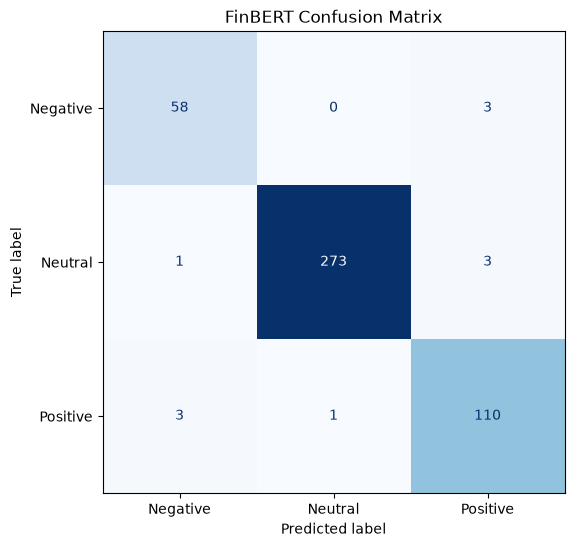

In [27]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("FinBERT Confusion Matrix")

plt.show()

### Observation

The confusion matrix visualizes the classification performance.

- The diagonal values represent correctly classified samples.
- Off-diagonal values indicate misclassifications.

A strong model produces high values along the diagonal and very few errors elsewhere.

In [28]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Value
0,Accuracy,0.975664
1,Precision,0.976011
2,Recall,0.975664
3,F1 Score,0.975793


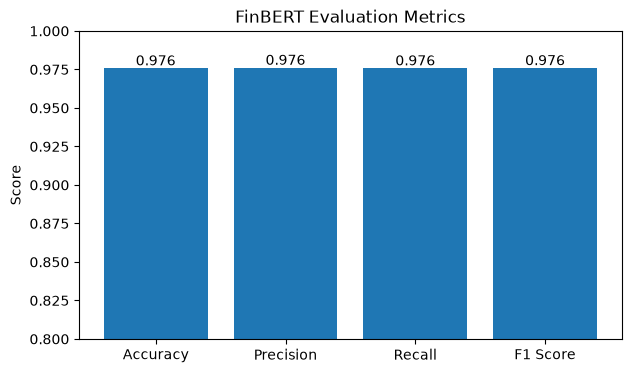

In [29]:
plt.figure(figsize=(7,4))

plt.bar(
    results["Metric"],
    results["Value"]
)

plt.ylim(0.8, 1.0)

plt.title("FinBERT Evaluation Metrics")
plt.ylabel("Score")

for i, value in enumerate(results["Value"]):
    plt.text(i, value + 0.002, f"{value:.3f}", ha="center")

plt.show()

# Section 5: Extract Financial News Embeddings

## Objective

The trained FinBERT model captures semantic information from financial news.

Instead of using only the predicted sentiment labels, we extract dense vector representations (embeddings) from the model.

These embeddings summarize the meaning of each news sentence in a numerical form.

The extracted embeddings will later be fused with the Temporal Fusion Transformer (TFT) features to build the final QuantFormer hybrid model.

In [30]:
from transformers import AutoModel

embedding_model = AutoModel.from_pretrained(MODEL_NAME)

embedding_model.load_state_dict(
    model.bert.state_dict(),
    strict=False
)

embedding_model.to(device)

embedding_model.eval()

print("Embedding Model Ready!")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19900.49it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding Model Ready!


In [31]:
def extract_embeddings(data_dict):

    embeddings = []

    with torch.no_grad():

        for i in range(data_dict["input_ids"].shape[0]):

            input_ids = data_dict["input_ids"][i].unsqueeze(0).to(device)

            attention_mask = data_dict["attention_mask"][i].unsqueeze(0).to(device)

            outputs = embedding_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embedding = outputs.last_hidden_state[:, 0, :]

            embeddings.append(
                cls_embedding.squeeze().cpu().numpy()
            )

    embeddings = np.array(embeddings)

    return embeddings

### Observation

For every financial news sentence, FinBERT produces contextual token representations.

The embedding corresponding to the **[CLS] token** is extracted because it summarizes the semantic meaning of the entire sentence.

In [32]:
train_embeddings = extract_embeddings(train_data)

print("Train Embeddings Shape:")

print(train_embeddings.shape)

Train Embeddings Shape:
(1807, 768)


In [33]:
val_embeddings = extract_embeddings(val_data)

print("Validation Embeddings Shape:")

print(val_embeddings.shape)

Validation Embeddings Shape:
(452, 768)


In [34]:
os.makedirs("../artifacts", exist_ok=True)

np.save(
    "../artifacts/train_finbert_embeddings.npy",
    train_embeddings
)

np.save(
    "../artifacts/val_finbert_embeddings.npy",
    val_embeddings
)

print("Embeddings Saved Successfully!")

Embeddings Saved Successfully!


### Observation

The extracted embeddings have been saved for later use.

Notebook 05 will load these embeddings and combine them with the Temporal Fusion Transformer outputs to build the multimodal QuantFormer architecture.

In [35]:
loaded_train = np.load("../artifacts/train_finbert_embeddings.npy")

loaded_val = np.load("../artifacts/val_finbert_embeddings.npy")

print("Train:", loaded_train.shape)

print("Validation:", loaded_val.shape)

Train: (1807, 768)
Validation: (452, 768)


# Notebook Summary

In this notebook:

- Loaded the preprocessed Financial PhraseBank dataset.
- Fine-tuned the pretrained FinBERT model.
- Achieved high sentiment classification performance.
- Evaluated the model using multiple metrics.
- Extracted semantic sentence embeddings.
- Saved embeddings for multimodal fusion.

These embeddings will serve as the textual representation of financial news in the final QuantFormer architecture.